# 2. Predictive Maintenance from Multivariate Sensor Streams
### Level: Intermediate | Data: Sensor (temperature, vibration, pressure, current) | Task: Supervised classification + RUL regression

**Industrial context.** A fleet of machines (compressors, CNC spindles, hydraulic pumps) streams
several sensor channels. As a machine degrades, the channels drift and get noisier. We want to:

1. **Classify**: will this machine fail within the next 30 operating cycles? (alarm for the maintenance planner)
2. **Regress**: estimate the **Remaining Useful Life (RUL)** in cycles

**What you'll learn**

* Simulating run-to-failure degradation data (in the spirit of NASA's C-MAPSS turbofan dataset)
* Rolling-window feature engineering
* The single most common mistake in PdM: **leakage from splitting by row instead of by machine**
* Evaluating with precision/recall (failures are rare and false alarms are costly)

**Requirements:** `numpy pandas scikit-learn matplotlib`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
N_MACHINES = 120
SENSORS = ['temp_C', 'vib_rms', 'pressure_bar', 'current_A']

## 1. Simulate run-to-failure histories

Each machine runs for a random lifetime (150-400 cycles). Sensor channels start near a healthy
baseline and degrade non-linearly toward failure - with per-machine variation, so no two
machines look identical. This mimics real fleet data where each unit ages differently.

In [2]:
def simulate_machine(machine_id):
    life = rng.integers(150, 400)
    cyc = np.arange(life)
    frac = cyc / life                              # 0 = new, 1 = failed
    deg = frac ** rng.uniform(1.5, 3.0)            # degradation accelerates near end of life

    df = pd.DataFrame({
        'machine_id': machine_id,
        'cycle': cyc,
        'temp_C':       65 + rng.normal(0, 1.0) + 25*deg + rng.normal(0, 0.8, life),
        'vib_rms':     0.8 + rng.normal(0, .05) + 1.8*deg + rng.normal(0, 0.08, life)*(1+2*deg),
        'pressure_bar': 10 - rng.normal(0, 0.2) - 2.5*deg + rng.normal(0, 0.15, life),
        'current_A':    12 + rng.normal(0, 0.3) + 4.0*deg + rng.normal(0, 0.30, life),
    })
    df['RUL'] = life - 1 - cyc                     # remaining useful life in cycles
    return df

data = pd.concat([simulate_machine(i) for i in range(N_MACHINES)], ignore_index=True)
print(data.shape)
data.head()

(33273, 7)


,machine_id,cycle,temp_C,vib_rms,pressure_bar,current_A,RUL
0,0,0,64.013389,0.762292,9.958233,11.261381,385
1,0,1,64.362127,0.766265,10.076571,11.475733,384
2,0,2,63.932553,0.689420,9.631186,11.914528,383
3,0,3,64.774002,0.677889,9.979861,11.767292,382
4,0,4,65.798091,0.856946,9.823294,11.448973,381


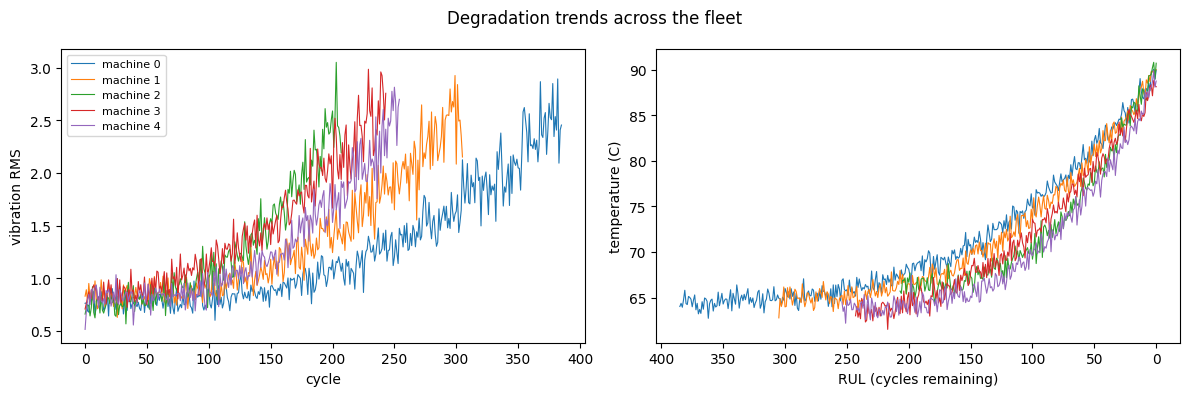

In [3]:
# Plot a few machines' vibration channel against RUL to see the degradation trend
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mid in [0, 1, 2, 3, 4]:
    d = data[data.machine_id == mid]
    axes[0].plot(d.cycle, d.vib_rms, lw=0.8, label=f'machine {mid}')
    axes[1].plot(d.RUL, d.temp_C, lw=0.8)
axes[0].set_xlabel('cycle'); axes[0].set_ylabel('vibration RMS'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('RUL (cycles remaining)'); axes[1].set_ylabel('temperature (C)')
axes[1].invert_xaxis()   # read left->right as "approaching failure"
plt.suptitle('Degradation trends across the fleet'); plt.tight_layout(); plt.show()

## 2. Feature engineering: rolling windows

A single noisy reading says little; the *trend* says a lot. For every sensor we add:

* rolling mean and rolling std over the last 20 cycles (level + noisiness)
* difference vs. 20 cycles ago (drift rate)

Rolling stats are computed **per machine** - never let a window straddle two machines.

In [4]:
W = 20
feat = data.copy()
for s in SENSORS:
    g = feat.groupby('machine_id')[s]
    feat[f'{s}_rmean'] = g.transform(lambda x: x.rolling(W, min_periods=5).mean())
    feat[f'{s}_rstd']  = g.transform(lambda x: x.rolling(W, min_periods=5).std())
    feat[f'{s}_slope'] = g.transform(lambda x: x.diff(W))
feat = feat.dropna().reset_index(drop=True)

HORIZON = 30
feat['fail_soon'] = (feat['RUL'] <= HORIZON).astype(int)   # classification target
FEATURES = [c for c in feat.columns if c not in ('machine_id', 'cycle', 'RUL', 'fail_soon')]
print(f'{len(FEATURES)} features, positive rate = {feat.fail_soon.mean():.1%}')

16 features, positive rate = 12.0%


## 3. Split by machine, not by row

If rows from the same machine appear in both train and test, the model effectively memorizes
each machine's baseline and the test score is a lie. We hold out **entire machines**.

In [5]:
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(np.arange(N_MACHINES), test_size=0.25, random_state=0)
train = feat[feat.machine_id.isin(train_ids)]
test  = feat[feat.machine_id.isin(test_ids)]

X_tr, y_tr = train[FEATURES], train['fail_soon']
X_te, y_te = test[FEATURES],  test['fail_soon']
print(f'train: {len(train_ids)} machines / {len(train):,} rows   test: {len(test_ids)} machines / {len(test):,} rows')

train: 90 machines / 23,649 rows   test: 30 machines / 7,224 rows


              precision    recall  f1-score   support

     healthy       0.99      0.97      0.98      6294
fails<=30cyc       0.84      0.93      0.88       930

    accuracy                           0.97      7224
   macro avg       0.91      0.95      0.93      7224
weighted avg       0.97      0.97      0.97      7224

average precision (PR-AUC): 0.956


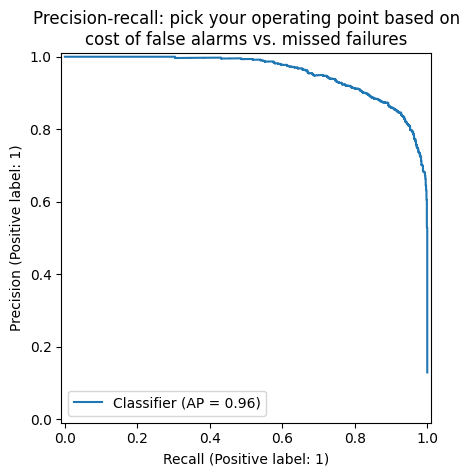

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, PrecisionRecallDisplay, average_precision_score

clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1,
                             class_weight='balanced', random_state=0)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
print(classification_report(y_te, proba > 0.5, target_names=['healthy', 'fails<=30cyc']))
print(f'average precision (PR-AUC): {average_precision_score(y_te, proba):.3f}')

PrecisionRecallDisplay.from_predictions(y_te, proba)
plt.title('Precision-recall: pick your operating point based on\ncost of false alarms vs. missed failures')
plt.show()

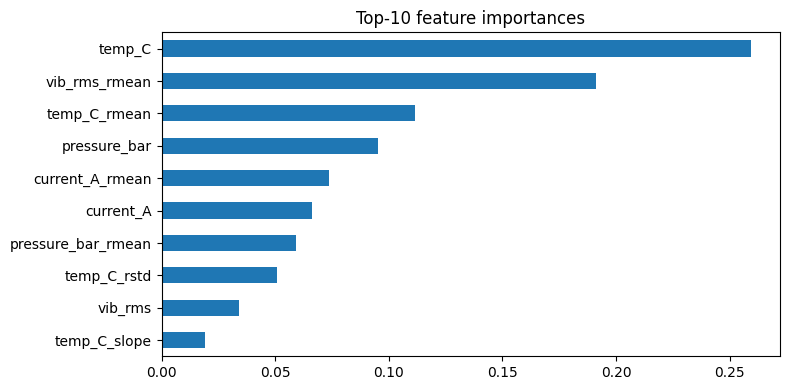

In [7]:
# Which signals drive the prediction?
imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
imp.tail(10).plot.barh(figsize=(8, 4), title='Top-10 feature importances')
plt.tight_layout(); plt.show()

## 4. Regression: estimate Remaining Useful Life

A binary alarm is useful; a countdown is better for scheduling. Same features, RUL target.
We clip the target at 130 cycles: early in life the exact RUL is unknowable from sensors
(the machine just looks healthy), and clipping is the standard C-MAPSS trick.

MAE: 8.7 cycles


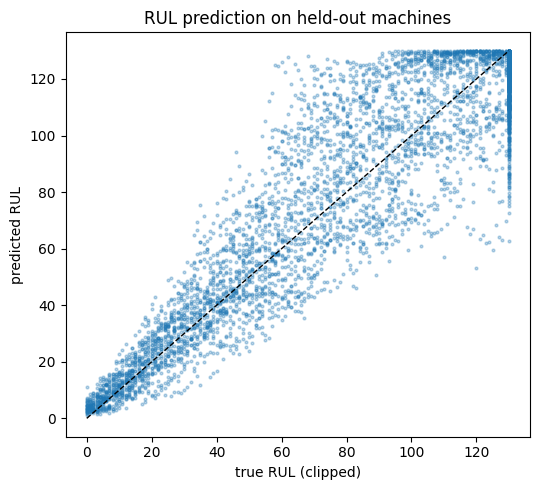

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

CLIP = 130
reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
reg.fit(X_tr, y_tr_rul := train['RUL'].clip(upper=CLIP))
pred_rul = reg.predict(X_te)
true_rul = test['RUL'].clip(upper=CLIP)
print(f'MAE: {mean_absolute_error(true_rul, pred_rul):.1f} cycles')

plt.figure(figsize=(5.5, 5))
plt.scatter(true_rul, pred_rul, s=4, alpha=0.3)
plt.plot([0, CLIP], [0, CLIP], 'k--', lw=1)
plt.xlabel('true RUL (clipped)'); plt.ylabel('predicted RUL')
plt.title('RUL prediction on held-out machines'); plt.tight_layout(); plt.show()

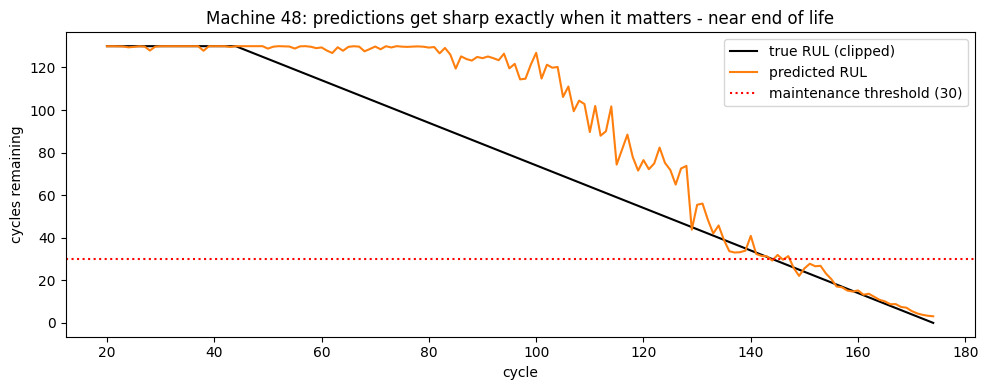

In [9]:
# Follow one held-out machine through its life: the predicted countdown
mid = test_ids[0]
d = test[test.machine_id == mid]
plt.figure(figsize=(10, 4))
plt.plot(d.cycle, d.RUL.clip(upper=CLIP), label='true RUL (clipped)', color='k')
plt.plot(d.cycle, reg.predict(d[FEATURES]), label='predicted RUL', color='tab:orange')
plt.axhline(HORIZON, color='r', ls=':', label=f'maintenance threshold ({HORIZON})')
plt.xlabel('cycle'); plt.ylabel('cycles remaining'); plt.legend()
plt.title(f'Machine {mid}: predictions get sharp exactly when it matters - near end of life')
plt.tight_layout(); plt.show()

## 5. Takeaways and next steps

* **Split by machine.** Re-run with a row-wise split and watch the scores become unrealistically perfect - that's leakage.
* Rolling trend features turn noisy point readings into a usable degradation signal.
* Precision/recall (not accuracy) is the right lens when only a small percentage of rows are "fails soon".
* **Try it yourself:** change `HORIZON`, add a cost matrix (false alarm = 1x, missed failure = 50x) and pick the threshold that minimizes expected cost.
* **Real data:** NASA C-MAPSS turbofan degradation and the AI4I 2020 predictive-maintenance dataset (UCI) are the standard next steps.
* Next notebook: switching to **image data** - a CNN that classifies surface defects.